# PyFC: Gaussian Priors on Nuisance Parameters (`extra_nll`)

Most real analyses do not measure every parameter from the data in front of them. A reactor
flux is known from someone else's measurement; a crustal abundance comes from a published
geochemical model; a detector energy scale is calibrated separately. Those external results
are *information*, and a fit that ignores them is throwing that information away.

This notebook is about the mechanism PyFC provides for putting it back: **`extra_nll`**, an
optional callable added to the negative log-likelihood at every evaluation.

## Hard constraints vs. soft ones

PyFC has three mechanisms that sound similar and do genuinely different things. Picking the
wrong one is easy, so it is worth being explicit about the distinction before any code.

| You want to say | Mechanism | Kind |
|---|---|---|
| "these parameters are linked by an inequality" (`f_e + f_mu <= 1`) | `constraints` | **hard** |
| "this free parameter's range depends on the one being scanned" | `bounds_func` | **hard** |
| "this parameter was *measured* to be `c ± s`" | **`extra_nll`** | **soft** |

`bounds_func` and `constraints` describe the **geometry** of parameter space: a point is
either allowed or forbidden, full stop. They are covered in
`06_pyfc_joint_constraints_tutorial.ipynb`.

`extra_nll` is different in kind. It does not forbid anything. It says some values are
*less likely* than others, and how much less, by adding a term to the likelihood. A
parameter with a preferred value `c` and a width `s` contributes a penalty that grows
quadratically as you move away from `c` -- so the fit can still go there, if the data
insists strongly enough, but it pays for it.

That is exactly what a prior from an external measurement is, and it is why the mechanism
is additive in log-likelihood space rather than a modification of the model.

> **Not to be confused with** the hand-rolled penalty the `optimizers.py` module docstring
> warns against. That warning is about multiplying your *rate* to suppress unphysical
> regions, which creates the flat-gradient trap PyFC works hard to avoid. `extra_nll` adds
> a term to the NLL and leaves your model untouched.

## ⚠️ Units: the one thing to get right

**PyFC's NLL is `-2 ln L`, not `-ln L`.**

This matters more than it looks. A Gaussian prior of width `s` about a centre `c`
contributes, in `-2 ln L` units:

$$\Delta(\mathrm{NLL}) = \left(\frac{x - c}{s}\right)^2$$

**not** the $\tfrac{1}{2}\left(\frac{x-c}{s}\right)^2$ you would write in a `-ln L`
convention, and which appears in a great many textbooks and papers.

Getting this wrong is *silent*. Nothing raises, nothing warns, the fit converges happily
and the interval looks entirely reasonable. What actually happens is that every one of your
constraints becomes weaker by a factor of $\sqrt{2}$ -- so a stated 4.6% prior quietly acts
as a 6.5% one, and your systematic uncertainties are all understated.

The first worked example below checks this numerically rather than asking you to take it on
faith, and gives you a one-line test you can run against your own penalty function.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

from pyfc.orchestrator import compute_fc_intervals
from pyfc.optimizers import unconditional_fit_scipy, conditional_fit_1d_scipy

np.random.seed(0)
print("PyFC ready")

Numba detected: JIT compilation enabled for maximum speed.


PyFC ready


## 1. A closed-form check of the units

Before doing anything physically interesting, let us pin the convention down with a case
that has an exact analytic answer.

Take a **single** parameter, and a model whose predicted rate does not depend on it at all.
The data therefore says nothing about the parameter, and the only thing constraining it is
the prior we supply. The likelihood is then *just* the prior, so the profile-likelihood test
statistic has a closed form:

$$t(x) = \left(\frac{x - c}{s}\right)^2$$

which means $t = z^2$ exactly at $x = c \pm z\,s$. That gives us a target to check against
rather than a number to eyeball: at one sigma the statistic must be exactly **1.0**, at two
sigma exactly **4.0**, at three sigma exactly **9.0**.

In [2]:
CENTRE, WIDTH = 1.2, 0.05          # "this parameter was measured to be 1.2 +- 0.05"
BOUNDS = [(0.5, 2.0)]
N_OBS  = np.array([50.0])
SUMW2  = np.array([0.0])

@njit(fastmath=True, nogil=True)
def flat_rate(params, S_sumw2, B_sumw2):
    """Predicted rate does not depend on the parameter -- only the prior constrains it."""
    return np.array([50.0]), S_sumw2

@njit(fastmath=True, nogil=True)
def correct_prior(params):
    """-2lnL convention: ((x - c)/s)**2, with NO factor of 0.5."""
    return ((params[0] - CENTRE) / WIDTH) ** 2

def half_prior(params):
    """The -lnL convention. Looks right, is wrong here -- sqrt(2) too weak."""
    return 0.5 * ((params[0] - CENTRE) / WIDTH) ** 2

def t_statistic(test_val, prior):
    """The profile-likelihood test statistic PyFC itself forms: cond - uncond."""
    uncond, _ = unconditional_fit_scipy(N_OBS, 1, BOUNDS, flat_rate,
                                        S_sumw2=SUMW2, B_sumw2=SUMW2, extra_nll=prior)
    cond, _ = conditional_fit_1d_scipy(test_val, 0, 1, N_OBS, BOUNDS, flat_rate,
                                       S_sumw2=SUMW2, B_sumw2=SUMW2, extra_nll=prior)
    return cond - uncond

print(f"{'z':>4}  {'expected t':>11}  {'correct form':>13}  {'with 0.5 factor':>16}")
for z in (1.0, 2.0, 3.0):
    x = CENTRE + z * WIDTH
    print(f"{z:>4.0f}  {z**2:>11.3f}  {t_statistic(x, correct_prior):>13.3f}"
          f"  {t_statistic(x, half_prior):>16.3f}")

   z   expected t   correct form   with 0.5 factor


   1        1.000          1.000             0.500
   2        4.000          4.000             2.000
   3        9.000          9.000             4.500


The middle column lands on $z^2$ to three decimals. The right-hand column is exactly half of
it -- which is what "a factor of $\sqrt{2}$ too weak" looks like from the other side: to
reach $t = 1$ with the `0.5` factor you have to travel $\sqrt{2}\,s$ instead of $s$.

**A test you can run on your own penalty.** Whatever your prior function looks like, this
must hold:

```python
assert t_statistic(c + s, my_prior) == pytest.approx(1.0, abs=1e-2)
```

If it comes out near `0.5`, you have the `-ln L` convention and every constraint in your
analysis is too weak.

## 2. Why this matters: a nuisance that eats the signal

The closed-form check above is reassuring but artificial. Here is the situation that
motivates the feature.

Consider a two-bin counting experiment. A signal strength `mu` is what we care about. A
background normalisation `b` is a nuisance -- we do not care about its value, but we have to
fit it, and it contributes to **both** bins. That overlap is the whole problem: raising `b`
and lowering `mu` can leave the prediction almost unchanged.

When two parameters can compensate for each other like that, the data alone cannot separate
them. The fit will happily explain a signal-free dataset with a large `mu` and a small `b`,
or vice versa, and the confidence interval on `mu` blows out.

But `b` is *not* unknown. Suppose it was measured elsewhere to 3%. Feeding that in collapses
the degeneracy, and on this toy it halves the upper limit on `mu` -- from the same data,
with no other change.

A two-bin toy understates the effect. In a realistic fit the degeneracies compound: in the
geoneutrino-decay analysis that prompted this feature, 11 of 13 parameters carry Gaussian
constraints, and removing them did not widen the limit so much as remove it -- the
normalisations simply absorbed the signal.

In [3]:
# Two bins. mu is the parameter of interest, b the nuisance -- and b appears in BOTH bins,
# so it can partially mimic a change in mu. That is what makes the pair hard to separate.
@njit(fastmath=True, nogil=True)
def degenerate_rate(params, S_sumw2, B_sumw2):
    mu, b = params[0], params[1]
    return np.array([12.0 * mu + 10.0 * b,
                     2.0 * mu + 10.0 * b]), S_sumw2

TRUE = np.array([0.0, 1.0])          # no signal, background at its nominal value
DATA = np.array([10.0, 10.0])        # exactly what TRUE predicts (an Asimov dataset)
S2   = np.zeros(2)

B_CENTRE, B_WIDTH = 1.0, 0.03        # "the background is known to 3%"

@njit(fastmath=True, nogil=True)
def background_prior(params):
    return ((params[1] - B_CENTRE) / B_WIDTH) ** 2

GRIDS = [np.linspace(0.0, 1.2, 7),   # mu: bounded below by zero, as a rate must be
         np.linspace(0.7, 1.3, 5)]   # b
print("model defined")

model defined


We now run the full Feldman-Cousins construction twice on the *same* data -- once with the
background free, once with the prior applied -- and compare the accepted region for `mu`.

Everything else is held fixed, so any difference is attributable to the prior alone.

  background FREE                accepted mu [0.00, 0.80]   (71% of the scanned range)
  background CONSTRAINED to 3%   accepted mu [0.00, 0.40]   (43% of the scanned range)


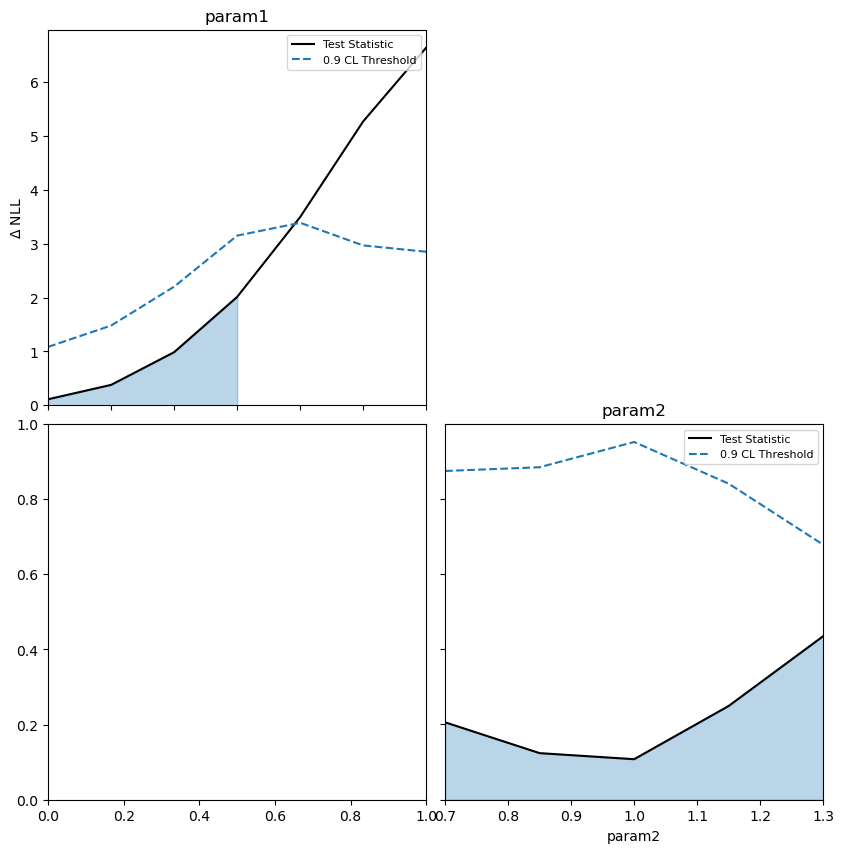

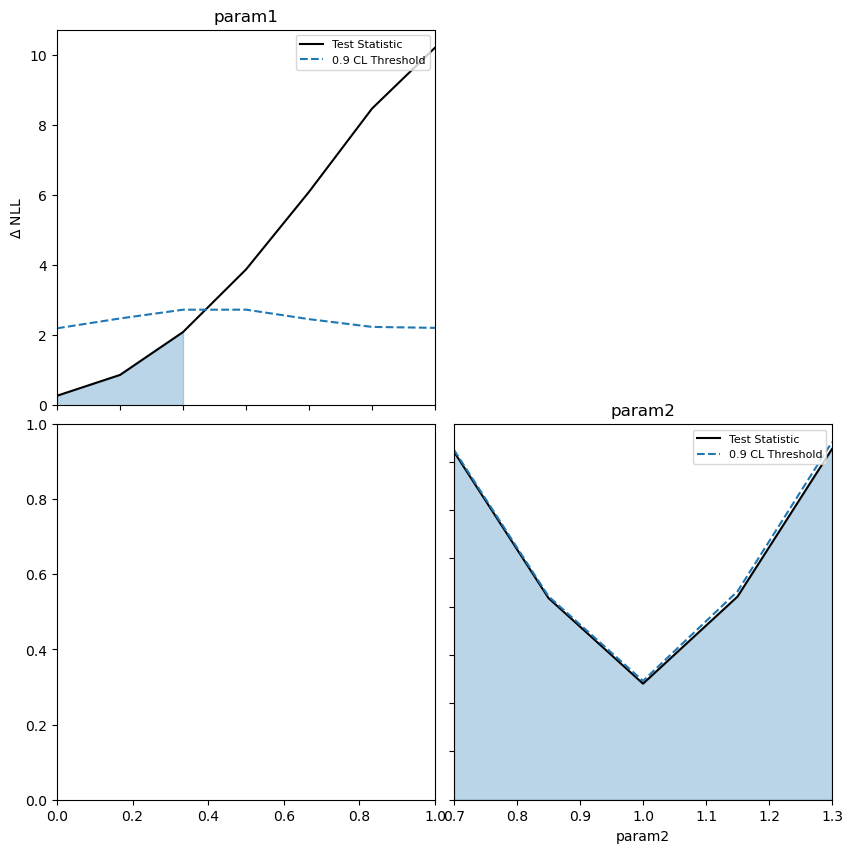

In [4]:
def run(extra_nll, tag):
    np.random.seed(4)
    results, _ = compute_fc_intervals(
        data=DATA, grids=GRIDS, compute_rates_func=degenerate_rate,
        cl=[0.90], n_toys=40, strategy="scipy", num_cores=1, verbose=0,
        sparsify_grid=False, warm_start=False, likelihood_type="binned",
        S_sumw2=S2, B_sumw2=S2, use_finite_mc_correction_binned=False,
        output_file=None, save_directory=f"gaussian_priors_output/{tag}",
        compute_1D_intervals=True, compute_2D_intervals=False,
        extra_nll=extra_nll,
    )
    return results

free = run(None,             "free")
tied = run(background_prior, "tied")

mu_grid = GRIDS[0]
for label, res in (("background FREE", free), ("background CONSTRAINED to 3%", tied)):
    acc = res["1d_accepted_p1"][0.90]
    inside = mu_grid[acc]
    span = f"[{inside.min():.2f}, {inside.max():.2f}]" if inside.size else "(empty)"
    frac = f"{100 * acc.sum() / acc.size:.0f}%"
    print(f"  {label:30s} accepted mu {span}   ({frac} of the scanned range)")

With the background free, 71% of the scanned range for `mu` survives; with the 3% prior,
43% does. The upper edge of the accepted region moves from 0.80 down to 0.40 -- the limit on
the signal strength tightens by a factor of two, from the *same data*, purely by supplying
what was already known about the background.

Two honest caveats about this particular demonstration:

* The effect here is a factor of two, not the total collapse described in the introduction.
  This is a deliberately small two-bin toy with a coarse 7-point grid and only 40 toys per
  point, chosen so the notebook runs in seconds. The degeneracy is real but mild. In an
  analysis with 13 parameters and many overlapping components, the degeneracies compound and
  the effect is correspondingly larger -- which is how a limit disappears entirely rather
  than merely widening.
* Neither run excludes `mu = 0`, which is correct: the data *is* the no-signal expectation.
  What changes is how much signal you can hide in the background, and that is precisely what
  the prior pins down.

**The failure mode is still the point.** The unconstrained run does not crash and does not
warn. It returns a well-formed interval that is simply weaker than the evidence justifies,
and without the side-by-side comparison there is nothing to alert you.

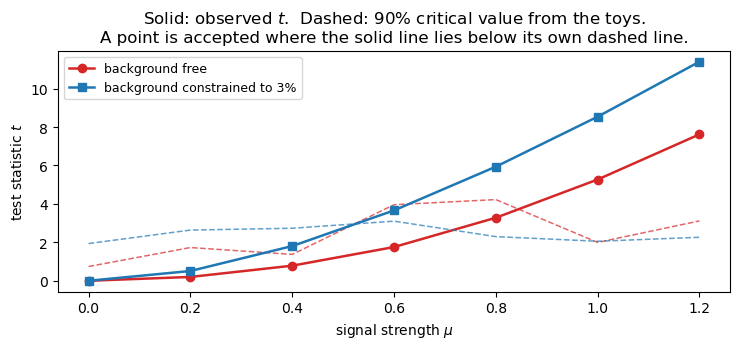

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for res, label, colour, marker in ((free, "background free", "tab:red", "o"),
                                   (tied, "background constrained to 3%", "tab:blue", "s")):
    ax.plot(mu_grid, res["1d_t_data_p1"], marker=marker, color=colour, label=label, lw=1.8)
    crit = np.asarray(res["1d_t_critical_p1"][0.90], dtype=float)
    ax.plot(mu_grid, crit, color=colour, ls="--", lw=1.1, alpha=0.7)

ax.set_xlabel(r"signal strength $\mu$")
ax.set_ylabel("test statistic $t$")
ax.set_title("Solid: observed $t$.  Dashed: 90% critical value from the toys.\n"
             "A point is accepted where the solid line lies below its own dashed line.")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

The dashed lines are worth a second look, because they are where the subtlety of this
feature lives.

Those are the **critical values**, built from Monte Carlo toys, and they are *different*
between the two runs. That is the point: `extra_nll` applies to the toy fits as well as the
data fit. If it applied only to the data, the observed statistic and the threshold it is
compared against would be computed under two different likelihoods, and the exact frequentist
coverage that Feldman-Cousins exists to deliver would be silently lost.

You would not see it in the output. The intervals would still be produced, still look
plausible, and simply not cover at the stated rate.

## 3. Many priors at once

Real analyses constrain more than one parameter. Write the whole set as a single vectorised
expression rather than a chain of additions -- it is faster, and it keeps the centres and
widths in one table you can read against your source document.

`extra_nll` is called once per NLL evaluation, which in a Feldman-Cousins run means a great
many times, so this function should stay cheap. Vectorised NumPy over a handful of
parameters is comfortably fast enough.

In [6]:
# One row per constrained parameter. Keeping them side by side like this makes the function
# auditable against wherever the numbers came from -- a paper, a calibration note, a
# collaboration-internal memo.
IDX     = np.array([1, 2, 3])                  # which parameters are constrained
CENTRES = np.array([1.00, 1.00, 1.00])
WIDTHS  = np.array([0.046, 0.11, 0.35])        # 4.6% reactor, 11% crust, 35% mantle

@njit(fastmath=True, nogil=True)
def multi_prior(params):
    # ((x - c)/s)**2 summed over the constrained subset. Note again: no factor of 0.5.
    return np.sum(((params[IDX] - CENTRES) / WIDTHS) ** 2)

# A quick sanity check: one sigma out on each parameter in turn should cost exactly 1.
p = np.ones(4)
print("cost at the centre of every prior:", multi_prior(p))
for k, (i, s) in enumerate(zip(IDX, WIDTHS)):
    q = p.copy()
    q[i] += s
    print(f"  parameter {i} displaced by 1 sigma ({s:>5.3f}) -> {multi_prior(q):.4f}")

cost at the centre of every prior: 0.0
  parameter 1 displaced by 1 sigma (0.046) -> 1.0000
  parameter 2 displaced by 1 sigma (0.110) -> 1.0000
  parameter 3 displaced by 1 sigma (0.350) -> 1.0000


Each single-sigma displacement costs exactly 1.0, and they add: displacing two parameters by
one sigma each costs 2.0. That additivity is what makes the vectorised form correct, and it
is worth checking once when you write the function rather than discovering later that a
broadcast went wrong.

## 4. Constraints a table of `(centre, width)` cannot express

`extra_nll` takes a **callable** rather than a list of triples, and that choice buys two
things a table cannot do.

**One-sided bounds.** A cosmological limit on a mass sum, or any "must be below X" result,
is not a Gaussian -- it is flat where the constraint is satisfied and rises only once you
cross the threshold. There is no `(centre, width)` pair that describes that shape.

**Constraints on derived quantities.** Sometimes the measured thing is not any single
parameter but a function of several -- a sum, a ratio, an asymmetry. A callable sees the
whole vector and can compute whatever it likes.

In [7]:
THRESHOLD, SOFTNESS = 2.5, 0.1

@njit(fastmath=True, nogil=True)
def one_sided_on_a_derived_sum(params):
    """Flat below the threshold, quadratic above it.

    The constrained quantity here is the SUM of three parameters -- not one of them -- which
    is exactly the case a table of (index, centre, width) triples cannot represent.
    """
    total = params[0] + params[1] + params[2]
    if total <= THRESHOLD:
        return 0.0                                     # no penalty: the bound is satisfied
    return ((total - THRESHOLD) / SOFTNESS) ** 2       # penalised once it is exceeded

for total in (2.0, 2.5, 2.6, 2.75):
    p = np.array([total / 3, total / 3, total / 3, 0.0])
    print(f"  sum = {total:.2f} -> penalty {one_sided_on_a_derived_sum(p):8.3f}")

  sum = 2.00 -> penalty    0.000
  sum = 2.50 -> penalty    0.000
  sum = 2.60 -> penalty    1.000
  sum = 2.75 -> penalty    6.250


Zero everywhere the bound holds, then rising quadratically past it. Note the penalty is
continuous at the threshold -- it starts from zero rather than jumping -- which keeps the
likelihood surface smooth enough for a gradient-based optimizer to work with. A
discontinuous penalty is a good way to confuse `L-BFGS-B`.

## 5. Practical notes

Three things worth knowing before putting this into a real analysis.

### `strategy="grid"` needs a jitted callable

The grid scan runs inside Numba-compiled code, which cannot call an arbitrary Python
function. With `strategy="grid"` your penalty must be decorated with `@njit`. PyFC checks
this up front and raises a `TypeError` telling you so -- without that check you would get a
Numba typing error that mentions neither `njit` nor which argument was at fault.

Every other strategy (`"scipy"`, `"ultranest"`, `"hybrid"`) accepts any Python callable.

### Unbinned toys are dispatched to processes

With `likelihood_type="unbinned"`, toy fits go to a `ProcessPoolExecutor`, which pickles its
arguments. A lambda or a closure cannot be pickled, so PyFC falls back to threads -- correct,
but slower. Define your penalty at module level to keep the process pool.

### It applies to every fit, including the toys

Already shown above, but worth repeating because it is the property that makes the feature
statistically sound rather than merely convenient.

In [8]:
# The grid guard in action: a plain Python function is rejected with an actionable message.
def plain_python_prior(params):
    return ((params[1] - B_CENTRE) / B_WIDTH) ** 2

try:
    compute_fc_intervals(
        data=DATA, grids=GRIDS, compute_rates_func=degenerate_rate,
        cl=[0.90], n_toys=3, strategy="grid", num_cores=1, verbose=0,
        sparsify_grid=False, warm_start=False, likelihood_type="binned",
        S_sumw2=S2, B_sumw2=S2, use_finite_mc_correction_binned=False,
        output_file=None, save_directory="gaussian_priors_output/guard",
        compute_1D_intervals=True, compute_2D_intervals=False,
        extra_nll=plain_python_prior,
    )
except TypeError as e:
    print("TypeError, as intended:\n")
    print(str(e))

TypeError, as intended:

extra_nll must be a numba-jitted function when strategy='grid', because the grid scan runs inside @njit code that cannot call a plain Python callable. Decorate it, e.g.:
    from numba import njit
    @njit(fastmath=True, nogil=True)
    def my_penalty(params):
        return ((params[0] - 1.0) / 0.05) ** 2
Alternatively use strategy='scipy', 'ultranest' or 'hybrid', which accept any Python callable.


## Summary

* `extra_nll(params) -> float` adds a term to the NLL at every evaluation. It is the
  mechanism for **soft** constraints -- external measurements of nuisance parameters --
  as distinct from `bounds_func` and `constraints`, which are **hard** geometry.
* **PyFC's NLL is `-2 ln L`**, so a Gaussian of width `s` contributes `((x - c)/s)**2`.
  The `0.5` factor from the `-ln L` convention makes every constraint $\sqrt{2}$ too weak,
  silently. Check it with `t(c + s) == 1.0`.
* It receives the **full** parameter vector in `grids` order, with any scan-fixed values
  already substituted, so one function works for the unconditional fit, the 1D scan and the
  2D scan alike.
* It applies to the **toy** fits as well as the data fits, which is what preserves the
  coverage guarantee.
* Being a callable rather than a table, it also expresses one-sided bounds and constraints
  on derived quantities.
* With `strategy="grid"` it must be `@njit`-decorated.

## Next steps

* `06_pyfc_joint_constraints_tutorial.ipynb` -- the other half of the constraint story:
  `bounds_func` and `constraints` for *hard* relations between parameters. The two compose;
  a model can use both.
* `01_pyfc_quickstart_tutorial.ipynb` -- the basic binned/unbinned workflow, if you have not
  started there.
* The README section *"Soft Constraints on Nuisance Parameters (`extra_nll`)"* and the
  `compute_fc_intervals` docstring, both of which carry the units warning in full.